In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os, pickle
from tqdm import tqdm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import scipy.optimize as opt
import scipy.sparse as sp

import jax.numpy as jnp
from jax import jit, random, lax, vmap
import argparse

from scipy.optimize import fsolve, minimize, curve_fit
from scipy.interpolate import CubicSpline, splrep, splev, UnivariateSpline
from scipy.signal import savgol_filter

plt.rcParams.update(
    {
        "mathtext.fontset": "stix",
        "font.family": "STIXGeneral",
        "legend.fontsize": 16,  # this is the font size in legends
        "xtick.labelsize": 16,  # this and next are the font of ticks
        "ytick.labelsize": 16,
        "axes.titlesize": 16,
        "axes.labelsize": 24,  # this is the fonx of axes labels
        "savefig.format": "pdf",  # how figures should be saved
        "legend.edgecolor": "0.0",
        "legend.framealpha": 1.0,
    }
)


output_folder = "fig1/"
os.system("mkdir -p " + output_folder)

plasmamap = plt.cm.plasma
virimap = plt.cm.viridis

# Parameters and functions for analysis and visualization

In [2]:
parser = argparse.ArgumentParser(description="ZTS_radial_v1_debug")

# parameters for the grid
parser.add_argument("--Lr", type=float, default=60, help="radial domain size")
parser.add_argument("--Lz", type=float, default=40, help="vertical domain size")
parser.add_argument(
    "--nr", type=int, default=128, help="number of points in the radial direction"
)
parser.add_argument(
    "--nz", type=int, default=128, help="number of points in the vertical direction"
)

# interaction parameters
parser.add_argument(
    "--chi-psi", type=float, default=0.0, help="chi parameter for psi (membrane)"
)
parser.add_argument(
    "--chi-phi", type=float, default=2.5, help="chi parameter for phi (bulk)"
)
parser.add_argument(
    "--lmda-phi", type=float, default=1.0, help="gradient coefficient for phi (bulk)"
)
parser.add_argument(
    "--lmda-psi",
    type=float,
    default=1.0,
    help="gradient coefficient for psi (membrane)",
)
parser.add_argument(
    "--h0",
    type=float,
    default=0.0,
    help="coupling coefficient between phi and the bare membrane",
)
parser.add_argument(
    "--h-phi-psi",
    type=float,
    default=1.0,
    help="coupling coefficient between phi and psi",
)

# mobility coefficients
parser.add_argument(
    "--m-phi", type=float, default=1.0, help="mobility coefficient for phi"
)
parser.add_argument(
    "--m-psi", type=float, default=1.0, help="mobility coefficient for psi"
)
flags = parser.parse_args("")

In [3]:
chi_psi, chi_phi = flags.chi_psi, flags.chi_phi
lmda_phi, lmda_psi = flags.lmda_phi, flags.lmda_psi
h_phi_psi = flags.h_phi_psi
h0 = flags.h0
M_phi, M_psi = flags.m_phi, flags.m_psi

In [4]:
########################################################################################
# construct the grid

dz = flags.Lz / flags.nz
dr = flags.Lr / flags.nr

r_left = jnp.arange(flags.nr) * dr
r_center = r_left + dr / 2
z_center = dz / 2 + jnp.arange(flags.nz) * dz


def plot_profile(phi, psi):
    fig = plt.figure(figsize=(6, 5), tight_layout=True)

    # Create a GridSpec with 2 rows and 1 column
    gs = gridspec.GridSpec(
        2, 1, height_ratios=[4, 1]
    )  # Adjust height_ratios to make axs[1] shorter

    # Create the first subplot
    ax1 = fig.add_subplot(gs[0])  # For the first plot (phi)
    c = ax1.imshow(
        phi,
        origin="lower",
        aspect="auto",
        extent=(0, flags.Lr, 0, flags.Lz),
        cmap=plasmamap,
        # vmin=0,
        # vmax=1,
    )
    ax1.set_ylabel("$z$")

    # Create the second subplot
    ax2 = fig.add_subplot(gs[1], sharex=ax1)  # Share x-axis with the first plot
    ax2.plot(r_center, psi)
    ax2.set_xlabel("$r$")
    ax2.set_ylabel("$\psi$")

    # Add the colorbar to the top of the first subplot
    cb = fig.colorbar(
        c,
        ax=ax1,
        orientation="horizontal",
        location="top",
        label="$\phi$",
        aspect=75,
    )
    return fig, ax1, ax2


phi_tol = 1e-8


def calc_f_entropy(psi):
    return psi * jnp.log(jnp.clip(psi, phi_tol, 1.0 - phi_tol)) + (1 - psi) * jnp.log(
        jnp.clip(1.0 - psi, phi_tol, 1.0 - phi_tol)
    )


def calc_f_uniform(psi, chi_psi):
    return calc_f_entropy(psi) + chi_psi * psi * (1 - psi)


def measure_contact_angle_fit(
    phi, phi_threshold, order=2, spherical_cap=False, psi=None
):
    # use the contour generated by the contour function; also does not work super well...
    if psi is None:
        psi = np.zeros_like(phi[0])

    fig, ax1, ax2 = plot_profile(phi, psi)
    c = ax1.contour(
        r_center,
        z_center,
        phi,
        levels=[phi_threshold],
        colors="tab:red",
        linestyles="--",
    )

    c_path = c.allsegs[0][0]
    # sort along the radial direction
    c_path = c_path[np.argsort(-c_path[:, 0])]
    # fit a polynomial to the last few points to determine the contact line
    # fit_end = np.max([np.argmax(c_path[:, 1] > 1), 3])

    if spherical_cap:
        # fit a spherical cap
        r_sphere_fun = lambda z, R0, z0: R0**2 - (z - z0) ** 2
        fit_mask = c_path[:, 1] > 1
        fitres_sphere = curve_fit(
            r_sphere_fun,
            c_path[fit_mask, 1],
            c_path[fit_mask, 0] ** 2,
            p0=[c_path.max() + 2, -c_path.max()],
        )
        fitres_sphere[0][0] = np.abs(fitres_sphere[0][0])  # ensure R0 is positive
        # print("fitres_sphere", fitres_sphere[0])
        if np.linalg.eigvals(fitres_sphere[1]).max() > 0.15:
            return np.nan, np.nan, (fig, ax1, ax2)
        cos_theta = -fitres_sphere[0][1] / fitres_sphere[0][0]
        r_contact = np.sqrt(r_sphere_fun(0, *fitres_sphere[0]))

        # plot the quality of the fit
        z_fit = np.linspace(0, c_path[:, 1].max(), 100)
        r_fit = np.sqrt(r_sphere_fun(z_fit, *fitres_sphere[0]))
        ax1.plot(r_fit, z_fit, "k--")
        return r_contact, cos_theta, (fig, ax1, ax2)
    else:
        # fit a polynomial
        plt.close(fig)

        fit_end = 4
        fitres = np.polyfit(c_path[:fit_end, 1], c_path[:fit_end, 0], order)
        # fit using higher order polynomials tend to diverge

        # compute the slope at z=0
        fitres_slope = -1 / fitres[-2]
        contact_line = np.poly1d(fitres)
        r_contact = contact_line(0)
        cos_theta = 1 / np.sqrt(1 + fitres_slope**2)
        return r_contact, cos_theta


########################################################################################
# determine binodal concentration
def convex_hull_1d(points):
    points = points[np.argsort(points[:, 0])]  # Sort by x-coordinates

    def cross(o, a, b):
        """2D cross product of OA and OB vectors (z-component)."""
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

    # Build lower hull
    lower = []
    for p in points:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(tuple(p))

    return np.array(lower)


def calc_binodal_spinodal(psi_mesh, f_mesh):
    xdata, ydata = psi_mesh, f_mesh

    # find the lower hull of the free energy
    points = np.column_stack((xdata, ydata))
    lower_hull = convex_hull_1d(points)

    # find binodal by comparing  free energy
    xmesh = np.linspace(psi_mesh[0], psi_mesh[-1], 10000)
    yinterp = np.interp(xmesh, xdata, ydata)
    yinterp_hull = np.interp(xmesh, lower_hull[:, 0], lower_hull[:, 1])

    df_threshold = 1e-6
    binodal_region = yinterp_hull < yinterp - df_threshold
    # find first and last non-zero region
    binodal_region_idx = np.where(binodal_region)[0]
    if len(binodal_region_idx) == 0:
        return [np.nan, np.nan], [np.nan, np.nan]

    psi_binodal = [xmesh[binodal_region_idx[0]], xmesh[binodal_region_idx[-1]]]

    # to determine spinodal, we need to compute the inflection point
    free_energy_derivative2 = CubicSpline(
        xdata,
        savgol_filter(ydata, window_length=5, polyorder=3, deriv=2)
        / (xdata[1] - xdata[0]) ** 2,
    )
    xmesh = np.linspace(psi_binodal[0], psi_binodal[1], 100)[1:-1]
    spinodal_region = free_energy_derivative2(xmesh) < 0
    spinodal_region_idx = np.where(spinodal_region)[0]
    if len(spinodal_region_idx) == 0:
        psi_spinodal = [np.nan, np.nan]
    psi_spinodal = [xmesh[spinodal_region_idx[0]], xmesh[spinodal_region_idx[-1]]]
    return psi_binodal, psi_spinodal


########################################################################################
phi_mesh = np.linspace(0, 1, 100000)
f_phi_mesh = calc_f_uniform(phi_mesh, chi_phi)
phi_binodal, phi_spinodal = calc_binodal_spinodal(phi_mesh, f_phi_mesh)
phi_boundary = min(phi_binodal)
phi_binodal_center = (phi_binodal[0] + phi_binodal[1]) / 2
########################################################################################

<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
/var/folders/mq/p5kn27bn3j927psc4z_49npm0000gn/T/ipykernel_71107/2541447402.py:37: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_ylabel("$\psi$")
/var/folders/mq/p5kn27bn3j927psc4z_49npm0000gn/T/ipykernel_71107/2541447402.py:45: SyntaxWarning: invalid escape sequence '\p'
  label="$\phi$",


# Equilibrium contact angle

In [5]:
psi_list = np.arange(1, 15) * 0.01
# h0_list = np.array([-0.1, -0.05, 0.0, 0.05])
h0_list = -0.15 + 0.05 * np.arange(5)  # from -0.2 to 0.2 in steps of 0.05
h0_str = [f"{h0:.2g}" for h0 in h0_list]
h0_str[np.where(np.abs(h0_list) < 1e-8)[0][0]] = "0.0"
h0_folder_list = [
    f"../data/data_flat_membrane//chi_psi_0.0_chi_phi_2.5_h0_{h0}_h1_1.0/"
    for h0 in h0_str
]
data_final = []
phi_final = []
psi_final = []

for h0_id in range(len(h0_list)):
    h0_folder = h0_folder_list[h0_id]
    data_final_profiles = [
        np.load(h0_folder + f"psi_{psi:.3f}/final_profile.npz") for psi in psi_list
    ]
    data_final.append(data_final_profiles)
    phi_final.append([data["phi"] for data in data_final_profiles])
    psi_final.append([data["psi"] for data in data_final_profiles])

In [6]:
psi_nucleus_list = np.zeros((len(h0_list), len(psi_list)))
phi_nucleus_list = np.zeros((len(h0_list), len(psi_list)))
phi_bulk_list = np.zeros((len(h0_list), len(psi_list)))
phi0_nucleus_list = np.zeros((len(h0_list), len(psi_list)))
phi0_bulk_list = np.zeros((len(h0_list), len(psi_list)))

for h0_id in range(len(h0_list)):
    for psi_id in range(len(psi_list)):
        z_id = np.argmax(np.diff(phi_final[h0_id][psi_id][:, 0], 2) < 0) + 1
        phi_nucleus_list[h0_id, psi_id] = phi_final[h0_id][psi_id][z_id, 0]
        psi_nucleus_list[h0_id, psi_id] = psi_final[h0_id][psi_id][0]
        phi_bulk_list[h0_id, psi_id] = phi_final[h0_id][psi_id][-1, 0]
        phi0_nucleus_list[h0_id, psi_id] = phi_final[h0_id][psi_id][0, 0]
        phi0_bulk_list[h0_id, psi_id] = phi_final[h0_id][psi_id][0, -1]

In [7]:
cos_theta = np.zeros((len(h0_list), len(psi_list)))
r_contact = np.zeros((len(h0_list), len(psi_list)))

for h0_id in range(len(h0_list)):
    for psi_id in range(len(psi_list)):
        (
            r_contact[h0_id, psi_id],
            cos_theta[h0_id, psi_id],
            (fig, ax1, ax2),
        ) = measure_contact_angle_fit(
            phi_final[h0_id][psi_id], phi_binodal_center, spherical_cap=True
        )
        plt.close(fig)

/var/folders/mq/p5kn27bn3j927psc4z_49npm0000gn/T/ipykernel_71107/2541447402.py:102: RuntimeWarning: invalid value encountered in sqrt
  r_contact = np.sqrt(r_sphere_fun(0, *fitres_sphere[0]))
/var/folders/mq/p5kn27bn3j927psc4z_49npm0000gn/T/ipykernel_71107/2541447402.py:106: RuntimeWarning: invalid value encountered in sqrt
  r_fit = np.sqrt(r_sphere_fun(z_fit, *fitres_sphere[0]))


## Fig. 1B: Plot a typical profile, and annotate

In [19]:
h0_id = np.where(np.abs(h0_list) < 1e-8)[0][0]
psi_id = 1
print("h0 = ", h0_list[h0_id])
print("psi = ", psi_list[psi_id])

h0 =  2.7755575615628914e-17
psi =  0.02


<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
/var/folders/mq/p5kn27bn3j927psc4z_49npm0000gn/T/ipykernel_71107/3432201408.py:7: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_ylabel("$\psi$")


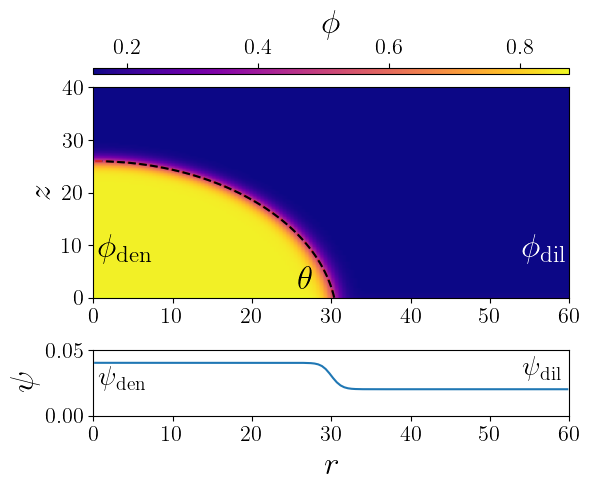

In [20]:
rr, coscos, (fig, ax1, ax2) = measure_contact_angle_fit(
    phi_final[h0_id][psi_id], phi_binodal_center, spherical_cap=True
)
ax2.cla()
ax2.plot(r_center, psi_final[h0_id][psi_id])
ax2.set_xlabel("$r$")
ax2.set_ylabel("$\psi$")
# add text for psi_l and psi_g
ax2.text(
    0.01,
    0.75,
    r"$\psi_\mathrm{den}$",
    transform=ax2.transAxes,
    verticalalignment="top",
    fontsize=20,
)
ax2.text(
    0.9,
    0.9,
    r"$\psi_\mathrm{dil}$",
    transform=ax2.transAxes,
    verticalalignment="top",
    fontsize=20,
)
ax2.set_ylim(0, 0.05)

# add text for theta, phi_l, phi_g
ax1.text(
    0.43,
    0.15,
    r"$\theta$",
    transform=ax1.transAxes,
    verticalalignment="top",
    fontsize=24,
)
ax1.text(
    0.01,
    0.3,
    r"$\phi_\mathrm{den}$",
    transform=ax1.transAxes,
    verticalalignment="top",
    fontsize=24,
)
ax1.text(
    0.9,
    0.3,
    r"$\phi_\mathrm{dil}$",
    transform=ax1.transAxes,
    verticalalignment="top",
    fontsize=24,
    color="white",
)
fig.savefig(output_folder + "Fig1B.pdf")

## Fig. 1C: Plot the tether enrichment level as function of tether abundance 

In [21]:
# define a colormap for h0

norm = mcolors.Normalize(vmin=h0_list.min(), vmax=h0_list.max())
cmap = plt.cm.viridis_r
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # only needed for older matplotlib versions

In [22]:
psi_mesh = np.linspace(0, psi_list[-1], 1000)
psi_theory = (
    psi_mesh
    * np.exp(h_phi_psi * (phi_binodal[1] - phi_binodal[0]))
    / (1 + psi_mesh * (np.exp(h_phi_psi * (phi_binodal[1] - phi_binodal[0])) - 1))
)

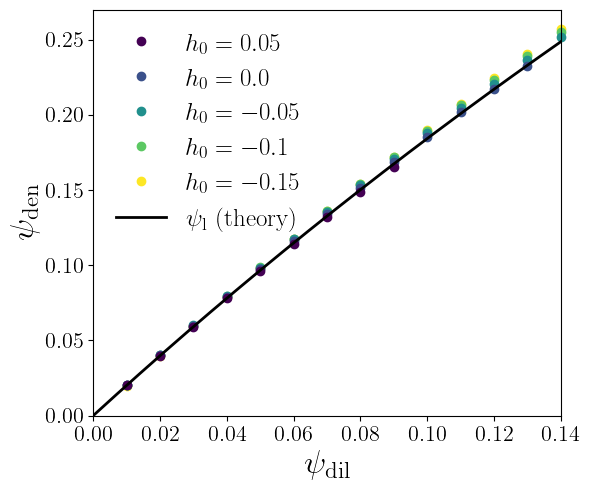

In [24]:
fig, ax = plt.subplots(figsize=(6, 5), tight_layout=True)
mask_converged = np.isfinite(cos_theta)
for h0_id in range(len(h0_list)):
    ax.plot(
        psi_list[mask_converged[h0_id]],
        psi_nucleus_list[h0_id][mask_converged[h0_id]],
        "o",
        label=f"$h_0={h0_str[h0_id]}$",
        # color=virimap((len(h0_list) - h0_id) / len(h0_list)),
        color=cmap(norm(h0_list[h0_id])),
        clip_on=False,
    )
ax.plot(
    psi_mesh,
    psi_theory,
    "-k",
    label=r"$\psi_\mathrm{l}$ (theory)",
    lw=2,
)

ax.set_xlim(0, psi_mesh[-1])
ax.set_ylim(0, None)
ax.set_xlabel(r"$\psi_\mathrm{dil}$")
ax.set_ylabel(r"$\psi_\mathrm{den}$")
handles, labels = ax.get_legend_handles_labels()
# flip the order
handles = handles[:-1][::-1] + handles[-1:]
labels = labels[:-1][::-1] + labels[-1:]

ax.legend(handles, labels, loc="upper left", frameon=False, ncol=1, fontsize=18)
fig.savefig(output_folder + "Fig1C.pdf", bbox_inches="tight")

## Fig. 1D: Plot the contact angle (force balance)

In [13]:
data_surface_tension = np.load("../data/chi_phi_2.5_surface_tension.npz")
sigma_lg = data_surface_tension["sigma_lg"]

sigma_0 = h0_list * (phi_binodal[1] - phi_binodal[0])
sigma_1_new = np.log(
    (1 + psi_mesh * (np.exp(h_phi_psi * (phi_binodal[1] - phi_binodal[0])) - 1))
)
cos_theta_theory = (sigma_0[:, np.newaxis] + sigma_1_new) / (sigma_lg)

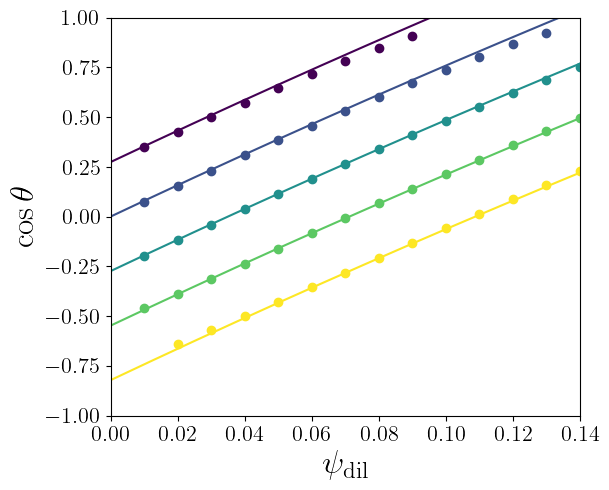

In [14]:
fig, ax = plt.subplots(figsize=(6, 5), tight_layout=True)
for h0_id in range(len(h0_list)):
    ax.plot(
        psi_list[mask_converged[h0_id]],
        cos_theta[h0_id][mask_converged[h0_id]],
        "o",
        color=cmap(norm(h0_list[h0_id])),
        label=f"$h_0={h0_str[h0_id]}$",
    )
    ax.plot(
        psi_mesh,
        cos_theta_theory[h0_id],
        "-",
        color=cmap(norm(h0_list[h0_id])),
    )

ax.set_xlim(0, psi_mesh[-1])
ax.set_ylim(-1, 1)
ax.set_xlabel(r"$\psi_\mathrm{dil}$")
ax.set_ylabel(r"$\cos\theta$")
fig.savefig(output_folder + "Fig1D.pdf", bbox_inches="tight")

## Fig. 1E: Plot the wetting phase diagram

In [15]:
h0 = -0.2
h1_mesh = np.linspace(0, 2, 100)
psi_g_mesh = np.linspace(0, 0.2, 100)[1:]
sigma_1_mesh = np.log(
    (
        1
        + psi_g_mesh
        * (np.exp(h1_mesh[:, np.newaxis] * (phi_binodal[1] - phi_binodal[0])) - 1)
    )
)
cos_theta_mesh = (h0 * (phi_binodal[1] - phi_binodal[0]) + sigma_1_mesh) / sigma_lg

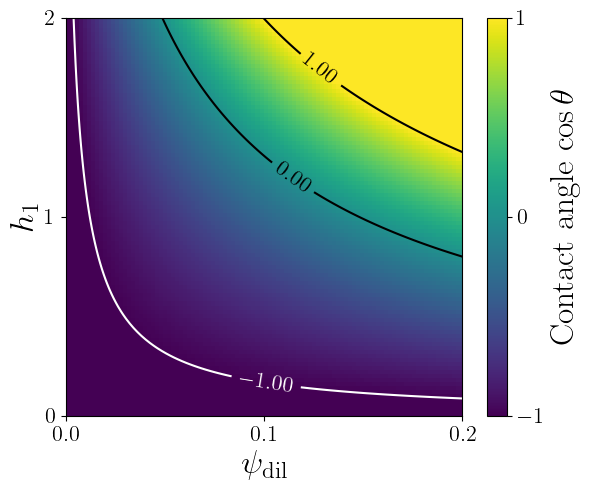

In [16]:
fig, ax = plt.subplots(figsize=(6, 5), tight_layout=True)
c = ax.pcolor(psi_g_mesh, h1_mesh, cos_theta_mesh, vmin=-1, vmax=1 + 1e-9)
cbar = fig.colorbar(c, ax=ax, ticks=[-1, 0, 1], pad=0.05)
c_contour = ax.contour(
    psi_g_mesh,
    h1_mesh,
    cos_theta_mesh,
    levels=[-1.0, 0, 1],
    colors=["white", "k", "k"],
)
clab = ax.clabel(
    c_contour,
    inline=True,
    fmt="$%1.2f$",
    fontsize=16,
    colors=["white", "k", "k"],
    manual=[(0.1, 0.1), (0.1, 1.0), (0.15, 2.0)],
)
cbar.set_label(r"Contact angle $\cos\theta$")
ax.set_xlabel(r"$\psi_\mathrm{dil}$")
ax.set_ylabel(r"$h_1$")
ax.set_xlim(0, psi_g_mesh[-1])
ax.set_ylim(0, h1_mesh[-1])
ax.set_yticks([0, 1, 2])
ax.set_xticks([0, 0.1, 0.2])
fig.savefig(f"{output_folder}/Fig1E.jpg", dpi=300)